In [15]:
import pandas as pd

df = pd.read_csv("Apple_Financial_Statements.csv")

df.head()
df.shape
df.columns

Index(['Year', 'EBITDA (millions)', 'Revenue (millions)',
       'Gross Profit (millions)', 'Op Income (millions)',
       'Net Income (millions)', 'EPS', 'Shares Outstanding',
       'Year Close Price', 'Total Assets (millions)',
       'Cash on Hand (millions)', 'Long Term Debt (millions)',
       'Total Liabilities (millions)', 'Gross Margin', 'PE ratio',
       'Employees'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          16 non-null     int64  
 1   EBITDA (millions)             16 non-null     int64  
 2   Revenue (millions)            16 non-null     int64  
 3   Gross Profit (millions)       16 non-null     int64  
 4   Op Income (millions)          16 non-null     int64  
 5   Net Income (millions)         16 non-null     int64  
 6   EPS                           16 non-null     float64
 7   Shares Outstanding            16 non-null     int64  
 8   Year Close Price              16 non-null     float64
 9   Total Assets (millions)       16 non-null     int64  
 10  Cash on Hand (millions)       16 non-null     int64  
 11  Long Term Debt (millions)     16 non-null     int64  
 12  Total Liabilities (millions)  16 non-null     int64  
 13  Gross M

In [19]:
df.isna().sum()

,0
Year,0
EBITDA (millions),0
Revenue (millions),0
Gross Profit (millions),0
Op Income (millions),0
Net Income (millions),0
EPS,0
Shares Outstanding,0
Year Close Price,0
Total Assets (millions),0


In [21]:
df.duplicated().sum()

np.int64(0)

In [23]:
df[['Year', 'Revenue (millions)', 'Net Income (millions)',
    'EPS', 'Year Close Price']].head(16)

,Year,Revenue (millions),Net Income (millions),EPS,Year Close Price
0,2009,42905,8235,0.32,6.3481
1,2010,65225,14013,0.54,9.7168
2,2011,108249,25922,0.99,12.2002
3,2012,156508,41733,1.58,16.1760
4,2013,170910,37037,1.42,17.4799
5,2014,182795,39510,1.61,24.5797
6,2015,233715,53394,2.31,23.8379
7,2016,215639,45687,2.08,26.8131
8,2017,229234,48351,2.30,39.8109
9,2018,265595,59531,2.98,37.6645


In [25]:
df['Revenue Growth %'] = df['Revenue (millions)'].pct_change() * 100

df[['Year', 'Revenue (millions)', 'Revenue Growth %']]

,Year,Revenue (millions),Revenue Growth %
0,2009,42905,NaN
1,2010,65225,52.021909
2,2011,108249,65.962438
3,2012,156508,44.581474
4,2013,170910,9.202086
5,2014,182795,6.953952
6,2015,233715,27.856342
7,2016,215639,-7.734206
8,2017,229234,6.304518
9,2018,265595,15.861958


In [27]:
df['Net Income Growth %'] = df['Net Income (millions)'].pct_change() * 100

df[['Year', 'Net Income (millions)', 'Net Income Growth %']]

,Year,Net Income (millions),Net Income Growth %
0,2009,8235,NaN
1,2010,14013,70.163934
2,2011,25922,84.985371
3,2012,41733,60.994522
4,2013,37037,-11.252486
5,2014,39510,6.677107
6,2015,53394,35.140471
7,2016,45687,-14.434206
8,2017,48351,5.830980
9,2018,59531,23.122583


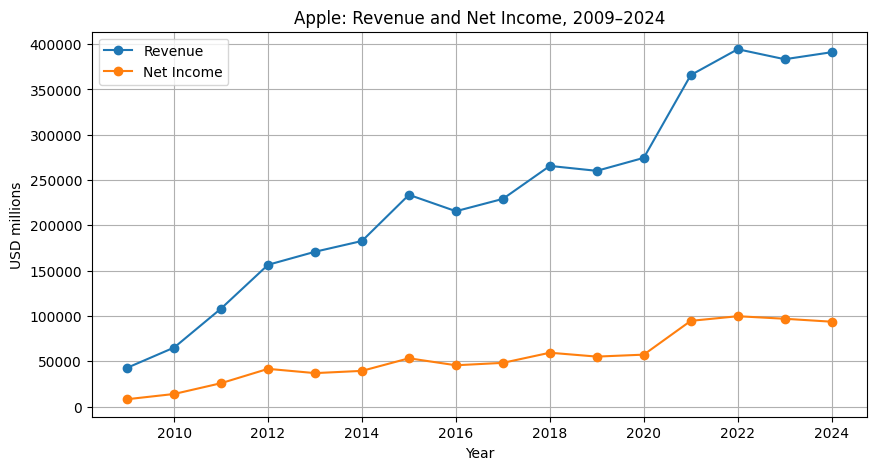

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['Revenue (millions)'],
    marker='o',
    label='Revenue'
)

plt.plot(
    df['Year'],
    df['Net Income (millions)'],
    marker='o',
    label='Net Income'
)

plt.title('Apple: Revenue and Net Income, 2009–2024')
plt.xlabel('Year')
plt.ylabel('USD millions')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
df['Net Margin %'] = (
    df['Net Income (millions)'] / df['Revenue (millions)']
) * 100

df[['Year', 'Revenue (millions)', 'Net Income (millions)', 'Net Margin %']]

,Year,Revenue (millions),Net Income (millions),Net Margin %
0,2009,42905,8235,19.193567
1,2010,65225,14013,21.484094
2,2011,108249,25922,23.946642
3,2012,156508,41733,26.665091
4,2013,170910,37037,21.670470
5,2014,182795,39510,21.614377
6,2015,233715,53394,22.845774
7,2016,215639,45687,21.186798
8,2017,229234,48351,21.092421
9,2018,265595,59531,22.414202


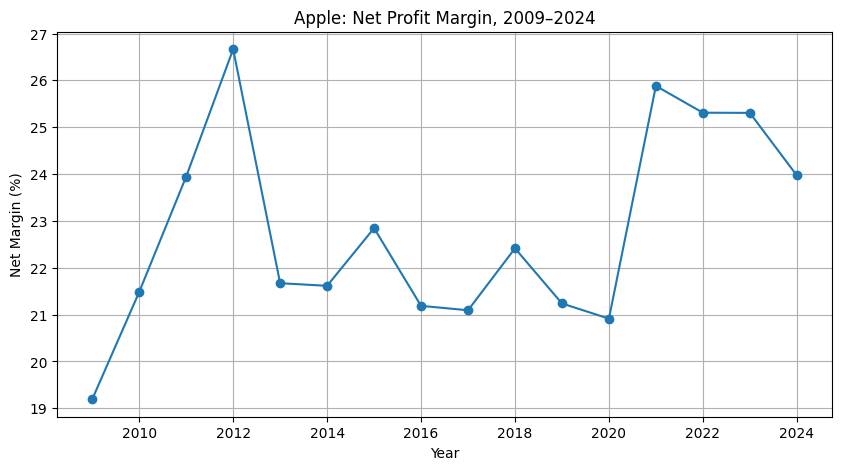

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['Net Margin %'],
    marker='o'
)

plt.title('Apple: Net Profit Margin, 2009–2024')
plt.xlabel('Year')
plt.ylabel('Net Margin (%)')
plt.grid(True)
plt.show()

In [36]:
df[['Revenue (millions)',
    'Net Income (millions)',
    'EPS',
    'Year Close Price',
    'Net Margin %']].describe()

,Revenue (millions),Net Income (millions),EPS,Year Close Price,Net Margin %
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,233745.562500,54455.875000,2.894375,72.092675,22.795879
std,111694.043224,28812.165067,2.019904,76.299400,2.141478
min,42905.000000,8235.000000,0.320000,6.348100,19.193567
25%,167309.500000,38891.750000,1.540000,17.153925,21.225270
50%,231474.500000,50872.500000,2.305000,32.238800,22.042336
75%,297340.500000,68082.250000,3.862500,128.875100,24.305000
max,394328.000000,99803.000000,6.130000,243.040000,26.665091


In [38]:
best_revenue_year = df.loc[df['Revenue (millions)'].idxmax(), 'Year']
best_revenue = df['Revenue (millions)'].max()

worst_revenue_year = df.loc[df['Revenue (millions)'].idxmin(), 'Year']
worst_revenue = df['Revenue (millions)'].min()

print("Максимальная выручка:")
print(best_revenue_year, best_revenue)

print("\nМинимальная выручка:")
print(worst_revenue_year, worst_revenue)

Максимальная выручка:
2022 394328

Минимальная выручка:
2009 42905


In [40]:
comparison = df[
    ['Year', 'Revenue Growth %', 'Net Income Growth %']
].copy()

comparison

,Year,Revenue Growth %,Net Income Growth %
0,2009,NaN,NaN
1,2010,52.021909,70.163934
2,2011,65.962438,84.985371
3,2012,44.581474,60.994522
4,2013,9.202086,-11.252486
5,2014,6.953952,6.677107
6,2015,27.856342,35.140471
7,2016,-7.734206,-14.434206
8,2017,6.304518,5.830980
9,2018,15.861958,23.122583


In [42]:
revenue_decline = df[df['Revenue Growth %'] < 0][
    ['Year', 'Revenue (millions)', 'Revenue Growth %']
]

revenue_decline

,Year,Revenue (millions),Revenue Growth %
7,2016,215639,-7.734206
10,2019,260174,-2.041078
14,2023,383285,-2.800461


In [44]:
profit_decline = df[df['Net Income Growth %'] < 0][
    ['Year', 'Net Income (millions)', 'Net Income Growth %']
]

profit_decline

,Year,Net Income (millions),Net Income Growth %
4,2013,37037,-11.252486
7,2016,45687,-14.434206
10,2019,55256,-7.181133
14,2023,96995,-2.813543
15,2024,93736,-3.359967


In [46]:
max_revenue_growth = df.loc[
    df['Revenue Growth %'].idxmax()
]

max_profit_growth = df.loc[
    df['Net Income Growth %'].idxmax()
]

print("Максимальный рост выручки:")
print(max_revenue_growth[['Year', 'Revenue Growth %']])

print("\nМаксимальный рост чистой прибыли:")
print(max_profit_growth[['Year', 'Net Income Growth %']])

Максимальный рост выручки:
Year                2011.000000
Revenue Growth %      65.962438
Name: 2, dtype: float64

Максимальный рост чистой прибыли:
Year                   2011.000000
Net Income Growth %      84.985371
Name: 2, dtype: float64


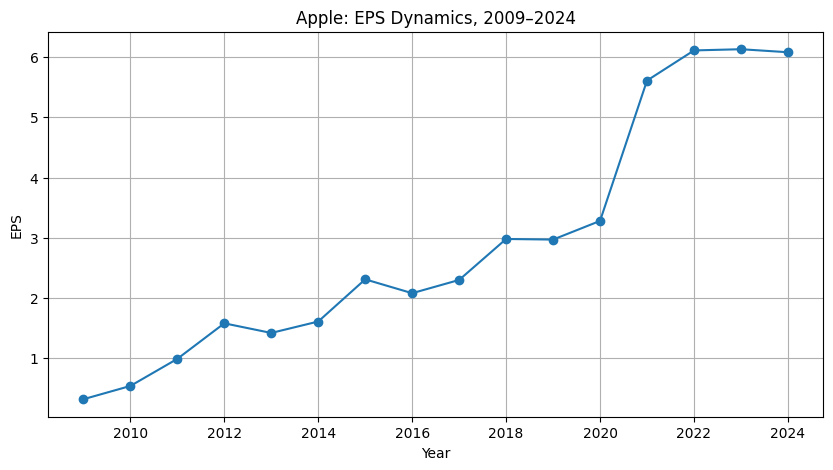

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    df['Year'],
    df['EPS'],
    marker='o'
)

plt.title('Apple: EPS Dynamics, 2009–2024')
plt.xlabel('Year')
plt.ylabel('EPS')
plt.grid(True)
plt.show()

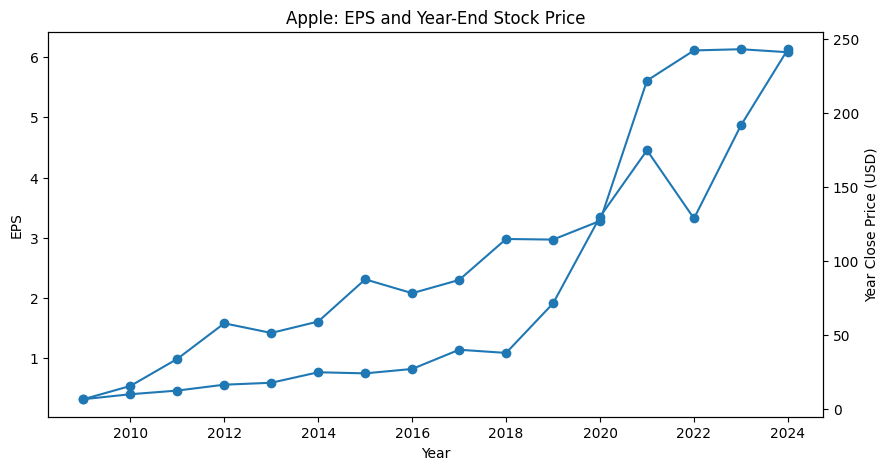

In [50]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    df['Year'],
    df['EPS'],
    marker='o',
    label='EPS'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('EPS')

ax2 = ax1.twinx()

ax2.plot(
    df['Year'],
    df['Year Close Price'],
    marker='o',
    label='Year Close Price'
)

ax2.set_ylabel('Year Close Price (USD)')

plt.title('Apple: EPS and Year-End Stock Price')
plt.show()

In [53]:
df.to_csv(
    "Apple_Financial_Analysis.csv",
    index=False
)

In [55]:
import sqlite3

conn = sqlite3.connect("apple_financial.db")

df.to_sql(
    "apple_financials",
    conn,
    if_exists="replace",
    index=False
)

print("Таблица создана")

Таблица создана


In [57]:
query = """
SELECT *
FROM apple_financials
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,Year,EBITDA (millions),Revenue (millions),Gross Profit (millions),Op Income (millions),Net Income (millions),EPS,Shares Outstanding,Year Close Price,Total Assets (millions),Cash on Hand (millions),Long Term Debt (millions),Total Liabilities (millions),Gross Margin,PE ratio,Employees,Revenue Growth %,Net Income Growth %,Net Margin %
0,2009,12474,42905,17222,11740,8235,0.32,25396,6.3481,47501,23464,0,15861,40.95,20.52,36800,NaN,NaN,19.193567
1,2010,19412,65225,25684,18385,14013,0.54,25892,9.7168,75183,25620,0,27392,38.76,15.19,49400,52.021909,70.163934,21.484094
2,2011,35604,108249,43818,33790,25922,0.99,26226,12.2002,116371,25952,0,39756,42.41,9.73,63300,65.962438,84.985371,23.946642
3,2012,58518,156508,68662,55241,41733,1.58,26470,16.1760,176064,29129,0,57854,41.91,10.27,76100,44.581474,60.994522,26.665091
4,2013,55756,170910,64304,48999,37037,1.42,26087,17.4799,207000,40546,16960,83451,37.41,12.14,84400,9.202086,-11.252486,21.670470


In [59]:
query = """
SELECT
    Year,
    "Revenue (millions)" AS Revenue
FROM apple_financials
ORDER BY "Revenue (millions)" DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Year,Revenue
0,2022,394328
1,2024,391035
2,2023,383285
3,2021,365817
4,2020,274515


In [61]:
query = """
SELECT
    Year,
    "Net Income (millions)" AS Net_Income
FROM apple_financials
ORDER BY "Net Income (millions)" DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Year,Net_Income
0,2022,99803
1,2023,96995
2,2021,94680
3,2024,93736
4,2018,59531


In [63]:
query = """
SELECT
    Year,
    "Revenue (millions)" AS Revenue,
    "Net Income (millions)" AS Net_Income,
    ROUND(
        "Net Income (millions)" * 100.0
        / "Revenue (millions)",
        2
    ) AS Net_Margin
FROM apple_financials
ORDER BY Year;
"""

pd.read_sql_query(query, conn)

,Year,Revenue,Net_Income,Net_Margin
0,2009,42905,8235,19.19
1,2010,65225,14013,21.48
2,2011,108249,25922,23.95
3,2012,156508,41733,26.67
4,2013,170910,37037,21.67
5,2014,182795,39510,21.61
6,2015,233715,53394,22.85
7,2016,215639,45687,21.19
8,2017,229234,48351,21.09
9,2018,265595,59531,22.41


In [65]:
query = """
SELECT
    Year,
    "Revenue (millions)" AS Revenue,
    "Net Income (millions)" AS Net_Income,
    ROUND(
        "Net Income (millions)" * 100.0
        / "Revenue (millions)",
        2
    ) AS Net_Margin
FROM apple_financials
ORDER BY Net_Margin DESC
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,Year,Revenue,Net_Income,Net_Margin
0,2012,156508,41733,26.67
1,2021,365817,94680,25.88
2,2022,394328,99803,25.31
3,2023,383285,96995,25.31
4,2024,391035,93736,23.97


In [67]:
df['EBITDA Margin %'] = (
    df['EBITDA (millions)'] / df['Revenue (millions)']
) * 100

df['Operating Margin %'] = (
    df['Op Income (millions)'] / df['Revenue (millions)']
) * 100

df['Debt to Assets %'] = (
    df['Long Term Debt (millions)'] / df['Total Assets (millions)']
) * 100

df[
    [
        'Year',
        'EBITDA Margin %',
        'Operating Margin %',
        'Net Margin %',
        'Debt to Assets %'
    ]
]

,Year,EBITDA Margin %,Operating Margin %,Net Margin %,Debt to Assets %
0,2009,29.073535,27.362778,19.193567,0.000000
1,2010,29.761594,28.187045,21.484094,0.000000
2,2011,32.890835,31.215069,23.946642,0.000000
3,2012,37.389782,35.295959,26.665091,0.000000
4,2013,32.623018,28.669475,21.670470,8.193237
5,2014,33.069285,28.722339,21.614377,12.503073
6,2015,35.293841,30.477291,22.845774,18.367459
7,2016,32.706978,27.835410,21.186798,23.447399
8,2017,31.191272,26.760428,21.092421,25.899835
9,2018,30.799149,26.694027,22.414202,25.629913


In [69]:
summary = df[
    [
        'Year',
        'Revenue (millions)',
        'Net Income (millions)',
        'EBITDA Margin %',
        'Operating Margin %',
        'Net Margin %',
        'Debt to Assets %',
        'EPS',
        'PE ratio'
    ]
].copy()

summary.round(2)

,Year,Revenue (millions),Net Income (millions),EBITDA Margin %,Operating Margin %,Net Margin %,Debt to Assets %,EPS,PE ratio
0,2009,42905,8235,29.07,27.36,19.19,0.00,0.32,20.52
1,2010,65225,14013,29.76,28.19,21.48,0.00,0.54,15.19
2,2011,108249,25922,32.89,31.22,23.95,0.00,0.99,9.73
3,2012,156508,41733,37.39,35.30,26.67,0.00,1.58,10.27
4,2013,170910,37037,32.62,28.67,21.67,8.19,1.42,12.14
5,2014,182795,39510,33.07,28.72,21.61,12.50,1.61,13.25
6,2015,233715,53394,35.29,30.48,22.85,18.37,2.31,10.12
7,2016,215639,45687,32.71,27.84,21.19,23.45,2.08,12.84
8,2017,229234,48351,31.19,26.76,21.09,25.90,2.30,16.37
9,2018,265595,59531,30.80,26.69,22.41,25.63,2.98,12.39


In [71]:
best_margin = df.loc[df['Net Margin %'].idxmax()]

print("Год с максимальной чистой маржой:")
print(int(best_margin['Year']))

print("Чистая маржа:")
print(round(best_margin['Net Margin %'], 2), "%")

Год с максимальной чистой маржой:
2012
Чистая маржа:
26.67 %


In [73]:
df[
    [
        'Year',
        'Long Term Debt (millions)',
        'Total Assets (millions)',
        'Debt to Assets %'
    ]
].round(2)

,Year,Long Term Debt (millions),Total Assets (millions),Debt to Assets %
0,2009,0,47501,0.00
1,2010,0,75183,0.00
2,2011,0,116371,0.00
3,2012,0,176064,0.00
4,2013,16960,207000,8.19
5,2014,28987,231839,12.50
6,2015,53329,290345,18.37
7,2016,75427,321686,23.45
8,2017,97207,375319,25.90
9,2018,93735,365725,25.63


In [74]:
df.to_csv(
    "Apple_Financial_Analysis.csv",
    index=False
)

print("Файл сохранён")

Файл сохранён
